# Notebook 03: Genre Performance

## Objective

This notebook examines which video game genres perform best after accounting for differences in the number of games released.

Genre performance is evaluated using:

- Number of games released
- Total global sales
- Average global sales per game
- Median global sales per game
- High-seller rate

A high-selling game is defined as a game with at least one million units in global sales.

## Research Question

**Which video game genres perform best after accounting for differences in the number of games released?**

The analysis addresses the limitation of ranking genres using total sales alone, because genres with more releases naturally have more opportunities to accumulate sales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Question 1 — Genre Performance

### Research Question

Which video game genres perform best after accounting for differences in the number of games released?

### Results

Genre performance is evaluated using:

- Number of games released
- Total global sales
- Average global sales per game
- Median global sales per game
- High-seller rate

A high-selling game is defined as a game with at least one million units in global sales.

In [4]:
data_path = Path("../data/processed/video_game_sales_cleaned.csv")

df = pd.read_csv(data_path)

df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.501450,0.350737,0.045564,0.102248,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.722664,0.088966,0.169235,0.019135,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.442367,0.359475,0.105777,0.092381,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.477273,0.333636,0.099394,0.089697,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.359146,0.283301,0.325685,0.031867,North America


In [5]:
required_columns = [
    "genre",
    "global_sales",
    "is_high_seller"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are available.")

All required columns are available.


In [6]:
df[required_columns].head()

,genre,global_sales,is_high_seller
0,Sports,82.74,1
1,Platform,40.24,1
2,Racing,35.82,1
3,Sports,33.00,1
4,Role-Playing,31.37,1


In [7]:
df[required_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 16287 entries, 0 to 16286
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   genre           16287 non-null  str    
 1   global_sales    16287 non-null  float64
 2   is_high_seller  16287 non-null  int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 381.9 KB


In [ ]:
genre_performance = (
    df.groupby("genre")
      .agg(
          release_count=("name", "count"),
          total_global_sales=("global_sales", "sum"),
          average_global_sales=("global_sales", "mean"),
          median_global_sales=("global_sales", "median"),
          high_seller_rate=("is_high_seller", "mean")
      )
      .reset_index()
)

## Because is_high_seller contains True/False or 1/0,
## taking its mean gives the proportion of high-selling games.

genre_performance["high_seller_rate_pct"] = (
    genre_performance["high_seller_rate"] * 100
)

genre_performance["total_global_sales"] = (
    genre_performance["total_global_sales"].round(2)
)

genre_performance["average_global_sales"] = (
    genre_performance["average_global_sales"].round(2)
)

genre_performance["median_global_sales"] = (
    genre_performance["median_global_sales"].round(2)
)

genre_performance["high_seller_rate_pct"] = (
    genre_performance["high_seller_rate_pct"].round(2)
)

genre_performance = genre_performance.drop(
    columns="high_seller_rate"
)

genre_performance.sort_values(
    by="average_global_sales",
    ascending=False
)

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
4,Platform,875,829.13,0.95,0.28,22.17
8,Shooter,1282,1026.20,0.80,0.23,19.42
7,Role-Playing,1468,923.79,0.63,0.19,13.83
6,Racing,1225,726.76,0.59,0.19,14.78
10,Sports,2304,1309.24,0.57,0.22,13.02
0,Action,3250,1722.83,0.53,0.19,12.89
2,Fighting,836,444.05,0.53,0.21,14.71
3,Misc,1686,789.87,0.47,0.16,9.96
9,Simulation,847,389.69,0.46,0.16,10.98
5,Puzzle,570,242.21,0.42,0.11,9.82


In [13]:
genre_by_release_count = genre_performance.sort_values(
    by="release_count",
    ascending=False
)

genre_by_release_count

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
0,Action,3250,1722.83,0.53,0.19,12.89
10,Sports,2304,1309.24,0.57,0.22,13.02
3,Misc,1686,789.87,0.47,0.16,9.96
7,Role-Playing,1468,923.79,0.63,0.19,13.83
8,Shooter,1282,1026.20,0.80,0.23,19.42
1,Adventure,1274,234.59,0.18,0.06,3.14
6,Racing,1225,726.76,0.59,0.19,14.78
4,Platform,875,829.13,0.95,0.28,22.17
9,Simulation,847,389.69,0.46,0.16,10.98
2,Fighting,836,444.05,0.53,0.21,14.71


In [19]:
genre_by_total_sales = genre_performance.sort_values(
    by="total_global_sales",
    ascending=False
)

genre_by_total_sales

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
0,Action,3250,1722.83,0.53,0.19,12.89
10,Sports,2304,1309.24,0.57,0.22,13.02
8,Shooter,1282,1026.20,0.80,0.23,19.42
7,Role-Playing,1468,923.79,0.63,0.19,13.83
4,Platform,875,829.13,0.95,0.28,22.17
3,Misc,1686,789.87,0.47,0.16,9.96
6,Racing,1225,726.76,0.59,0.19,14.78
2,Fighting,836,444.05,0.53,0.21,14.71
9,Simulation,847,389.69,0.46,0.16,10.98
5,Puzzle,570,242.21,0.42,0.11,9.82


In [14]:
genre_by_average_sales = genre_performance.sort_values(
    by="average_global_sales",
    ascending=False
)

genre_by_average_sales

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
4,Platform,875,829.13,0.95,0.28,22.17
8,Shooter,1282,1026.20,0.80,0.23,19.42
7,Role-Playing,1468,923.79,0.63,0.19,13.83
6,Racing,1225,726.76,0.59,0.19,14.78
10,Sports,2304,1309.24,0.57,0.22,13.02
0,Action,3250,1722.83,0.53,0.19,12.89
2,Fighting,836,444.05,0.53,0.21,14.71
3,Misc,1686,789.87,0.47,0.16,9.96
9,Simulation,847,389.69,0.46,0.16,10.98
5,Puzzle,570,242.21,0.42,0.11,9.82


In [15]:
genre_by_median_sales = genre_performance.sort_values(
    by="median_global_sales",
    ascending=False
)

genre_by_median_sales

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
4,Platform,875,829.13,0.95,0.28,22.17
8,Shooter,1282,1026.20,0.80,0.23,19.42
10,Sports,2304,1309.24,0.57,0.22,13.02
2,Fighting,836,444.05,0.53,0.21,14.71
7,Role-Playing,1468,923.79,0.63,0.19,13.83
6,Racing,1225,726.76,0.59,0.19,14.78
0,Action,3250,1722.83,0.53,0.19,12.89
3,Misc,1686,789.87,0.47,0.16,9.96
9,Simulation,847,389.69,0.46,0.16,10.98
5,Puzzle,570,242.21,0.42,0.11,9.82


In [16]:
genre_by_high_seller_rate = genre_performance.sort_values(
    by="high_seller_rate_pct",
    ascending=False
)

genre_by_high_seller_rate

,genre,release_count,total_global_sales,average_global_sales,median_global_sales,high_seller_rate_pct
4,Platform,875,829.13,0.95,0.28,22.17
8,Shooter,1282,1026.20,0.80,0.23,19.42
6,Racing,1225,726.76,0.59,0.19,14.78
2,Fighting,836,444.05,0.53,0.21,14.71
7,Role-Playing,1468,923.79,0.63,0.19,13.83
10,Sports,2304,1309.24,0.57,0.22,13.02
0,Action,3250,1722.83,0.53,0.19,12.89
9,Simulation,847,389.69,0.46,0.16,10.98
3,Misc,1686,789.87,0.47,0.16,9.96
5,Puzzle,570,242.21,0.42,0.11,9.82


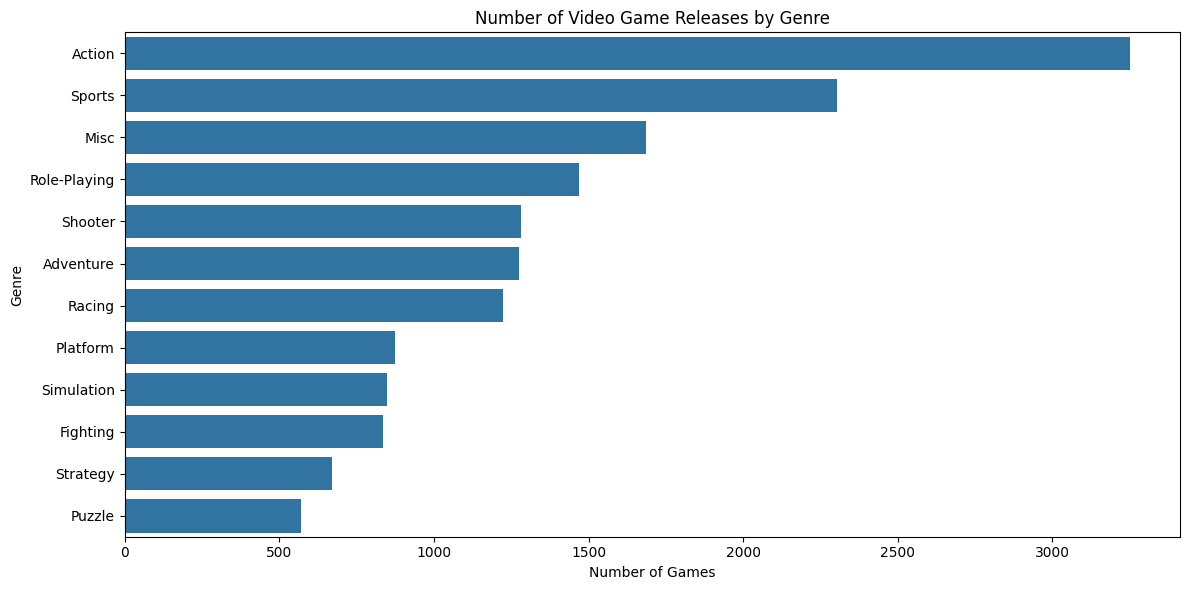

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_by_release_count,
    x="release_count",
    y="genre"
)

plt.title("Number of Video Game Releases by Genre")
plt.xlabel("Number of Games")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Action has the largest release volume, with Sports and Misc also representing especially large catalogs.

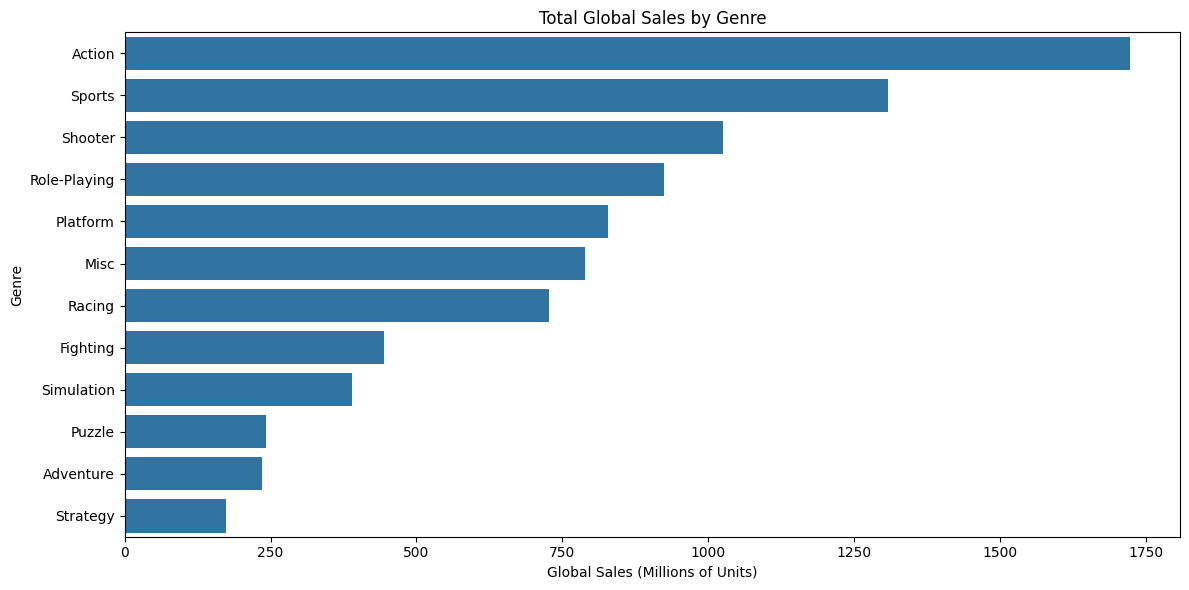

In [20]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_by_total_sales,
    x="total_global_sales",
    y="genre"
)

plt.title("Total Global Sales by Genre")
plt.xlabel("Global Sales (Millions of Units)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Action leads total global sales, followed by Sports and Shooter, showing that broad catalogs can translate into large commercial scale.

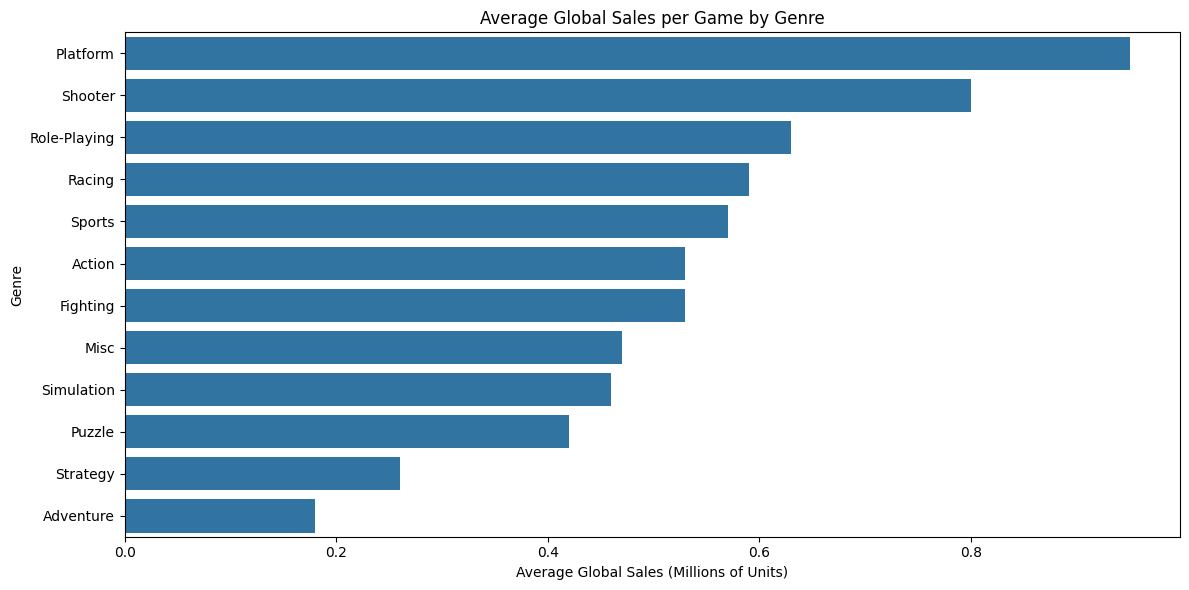

In [22]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_by_average_sales,
    x="average_global_sales",
    y="genre"
)

plt.title("Average Global Sales per Game by Genre")
plt.xlabel("Average Global Sales (Millions of Units)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Platform has the highest average sales per game, with Shooter next, indicating stronger per-title performance than the highest-volume genres.

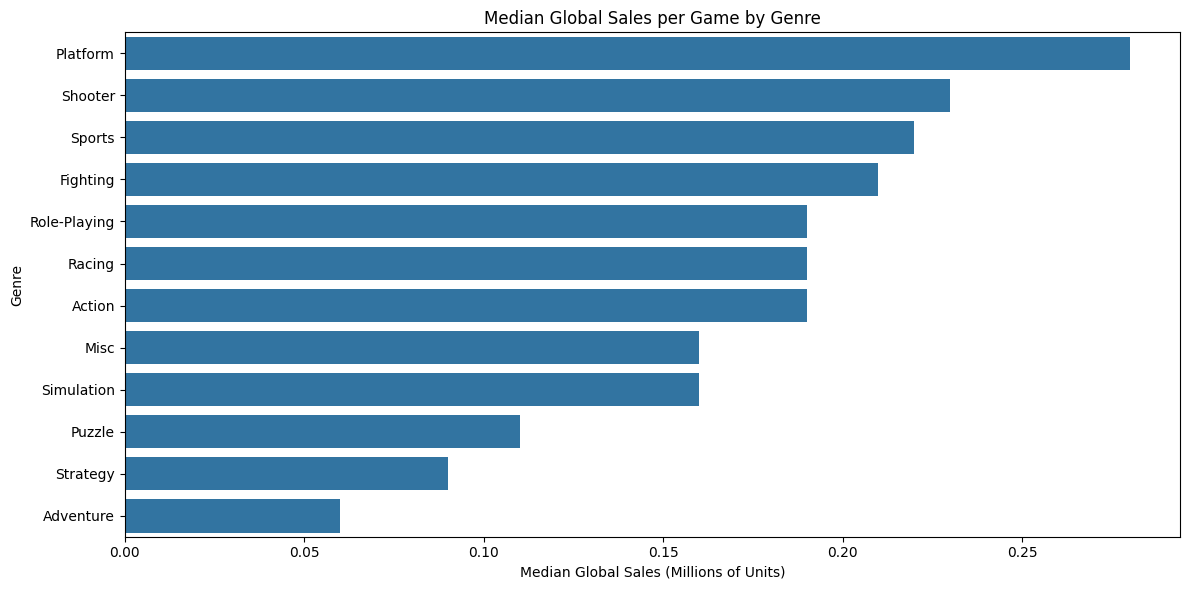

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_by_median_sales,
    x="median_global_sales",
    y="genre"
)

plt.title("Median Global Sales per Game by Genre")
plt.xlabel("Median Global Sales (Millions of Units)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Platform also leads on median sales, which suggests its advantage is not driven only by a few unusually large hits.

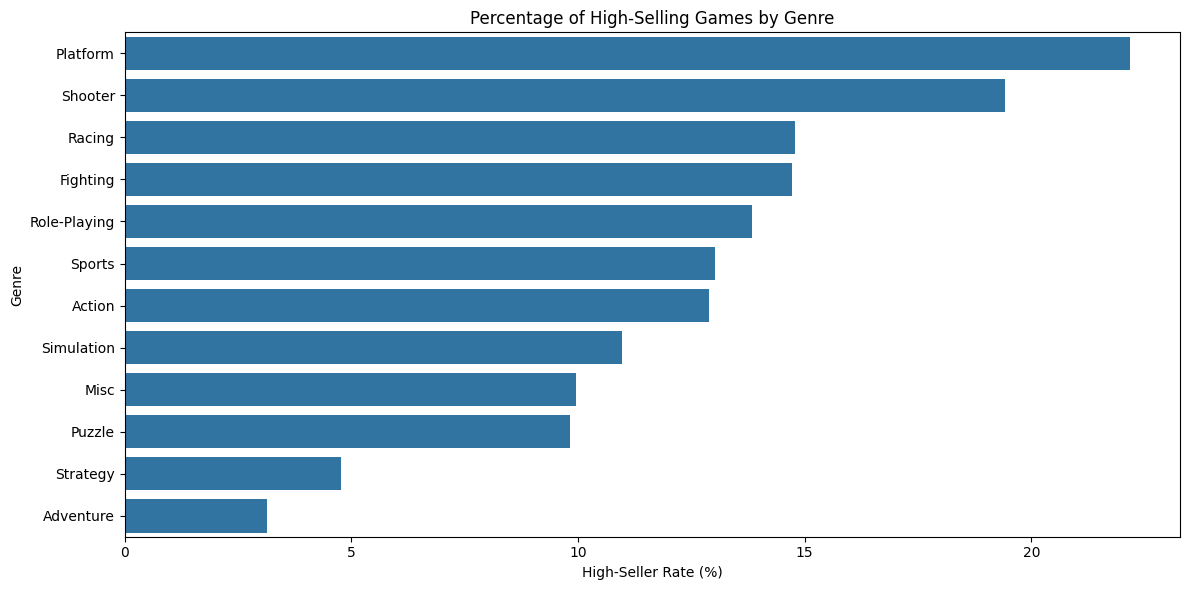

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=genre_by_high_seller_rate,
    x="high_seller_rate_pct",
    y="genre"
)

plt.title("Percentage of High-Selling Games by Genre")
plt.xlabel("High-Seller Rate (%)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Platform has the highest share of games selling at least one million units, with Shooter also standing out.

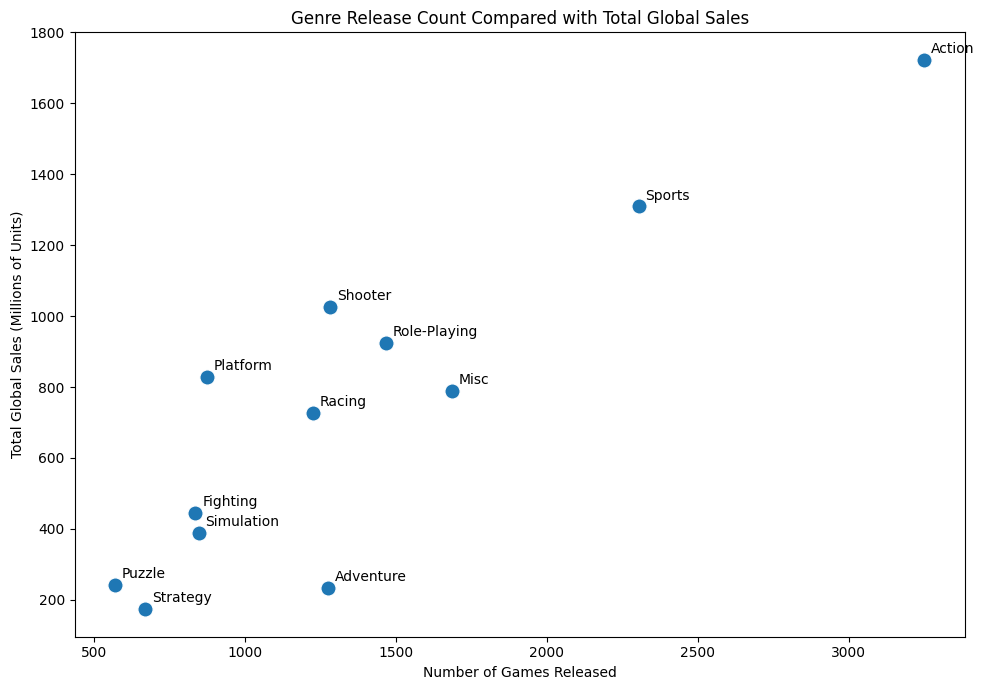

In [25]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=genre_performance,
    x="release_count",
    y="total_global_sales",
    s=120
)

for _, row in genre_performance.iterrows():
    plt.annotate(
        row["genre"],
        (row["release_count"], row["total_global_sales"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Genre Release Count Compared with Total Global Sales")
plt.xlabel("Number of Games Released")
plt.ylabel("Total Global Sales (Millions of Units)")

plt.tight_layout()
plt.show()

**Key takeaway:** Total global sales generally rise with release count, so Action's lead in total sales is closely tied to having many releases.

In [26]:
average_median_comparison = genre_performance[
    [
        "genre",
        "average_global_sales",
        "median_global_sales"
    ]
].melt(
    id_vars="genre",
    var_name="sales_measure",
    value_name="global_sales"
)

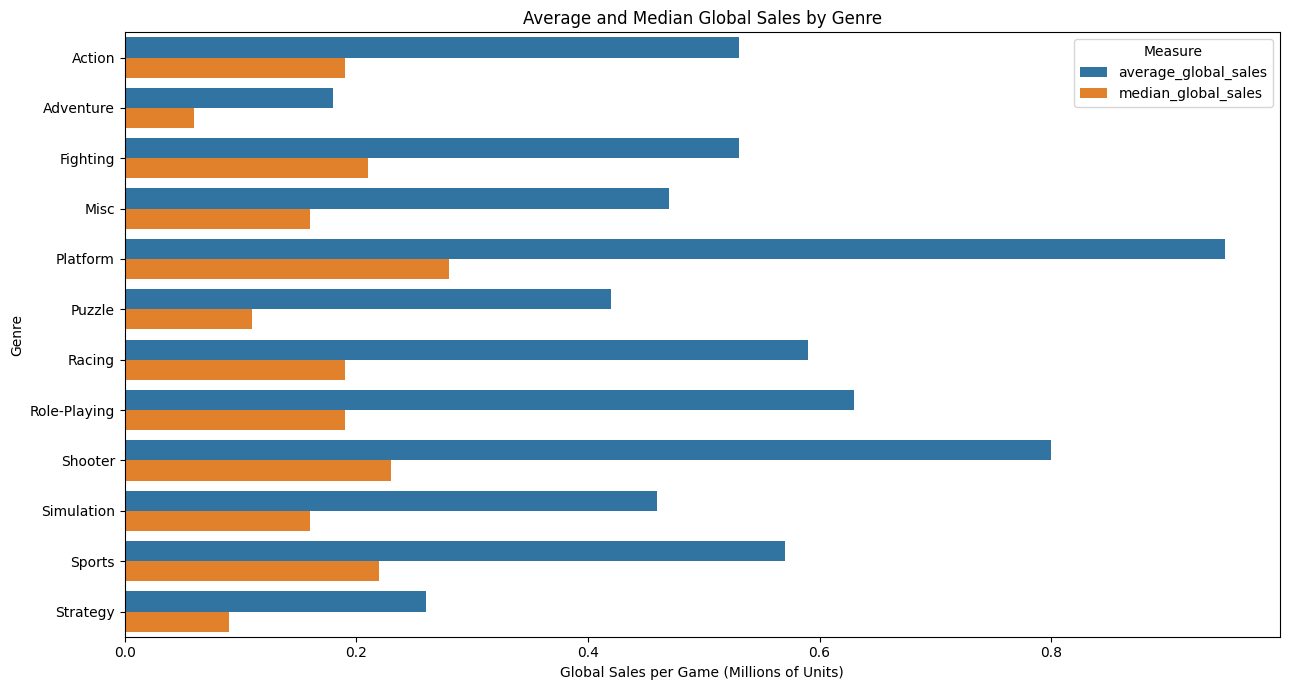

In [27]:
plt.figure(figsize=(13, 7))

sns.barplot(
    data=average_median_comparison,
    x="global_sales",
    y="genre",
    hue="sales_measure"
)

plt.title("Average and Median Global Sales by Genre")
plt.xlabel("Global Sales per Game (Millions of Units)")
plt.ylabel("Genre")
plt.legend(title="Measure")

plt.tight_layout()
plt.show()

**Key takeaway:** Averages are higher than medians across genres, confirming that a small number of major hits pull sales upward.

In [28]:
genre_order = (
    df.groupby("genre")["global_sales"]
      .median()
      .sort_values(ascending=False)
      .index
)

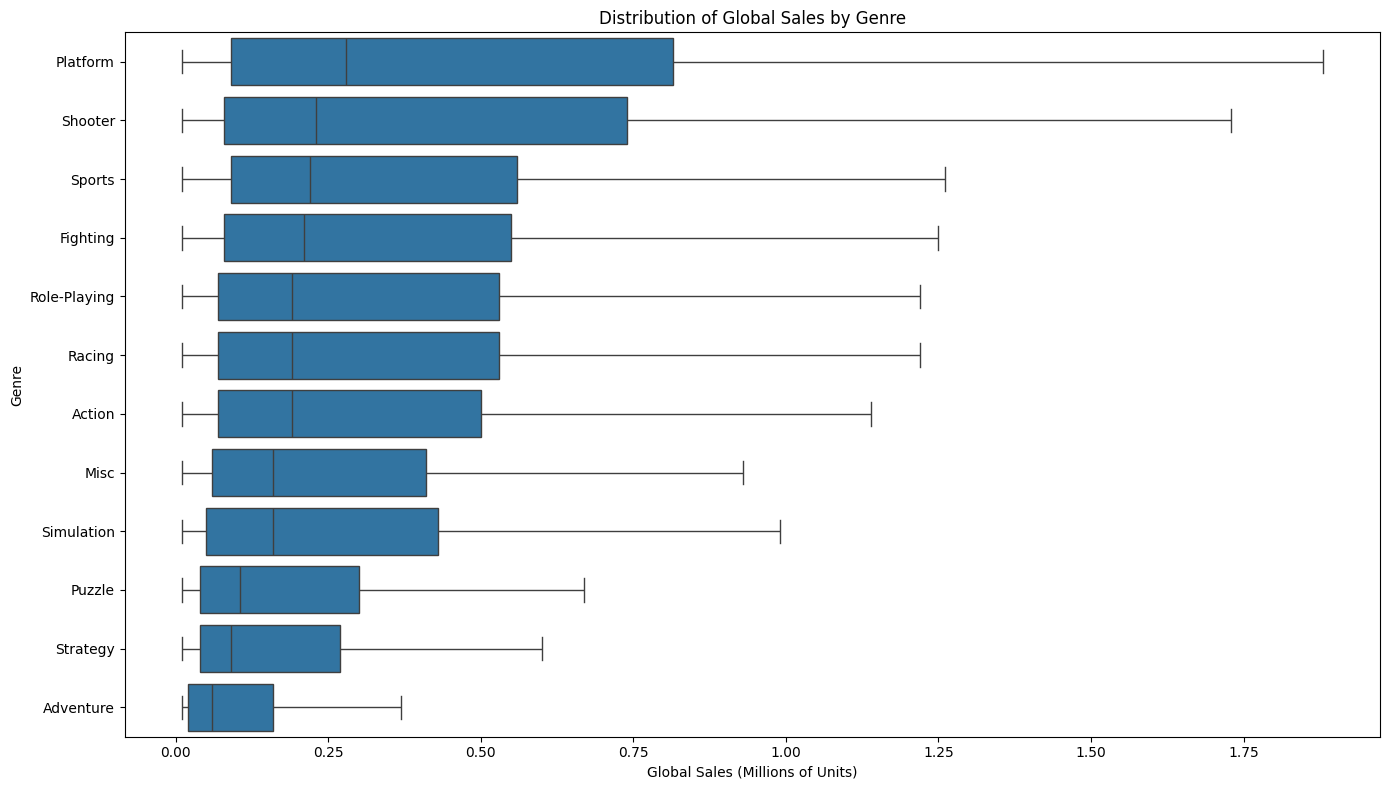

In [29]:
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="global_sales",
    y="genre",
    order=genre_order,
    showfliers=False
)

plt.title("Distribution of Global Sales by Genre")
plt.xlabel("Global Sales (Millions of Units)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

**Key takeaway:** Platform and Shooter show stronger typical sales distributions, while Adventure and Strategy are concentrated at lower sales levels. The wide upper ranges also show that sales vary considerably within most genres.

In [30]:
leading_genres = pd.DataFrame({
    "performance_measure": [
        "Release count",
        "Total global sales",
        "Average global sales",
        "Median global sales",
        "High-seller rate"
    ],
    "leading_genre": [
        genre_performance.loc[
            genre_performance["release_count"].idxmax(),
            "genre"
        ],
        genre_performance.loc[
            genre_performance["total_global_sales"].idxmax(),
            "genre"
        ],
        genre_performance.loc[
            genre_performance["average_global_sales"].idxmax(),
            "genre"
        ],
        genre_performance.loc[
            genre_performance["median_global_sales"].idxmax(),
            "genre"
        ],
        genre_performance.loc[
            genre_performance["high_seller_rate_pct"].idxmax(),
            "genre"
        ]
    ],
    "value": [
        genre_performance["release_count"].max(),
        genre_performance["total_global_sales"].max(),
        genre_performance["average_global_sales"].max(),
        genre_performance["median_global_sales"].max(),
        genre_performance["high_seller_rate_pct"].max()
    ]
})

leading_genres

,performance_measure,leading_genre,value
0,Release count,Action,3250.00
1,Total global sales,Action,1722.83
2,Average global sales,Platform,0.95
3,Median global sales,Platform,0.28
4,High-seller rate,Platform,22.17


### Interpretation

The results show that genre performance changes depending on whether success is measured using total sales or sales per game.

Action was the most frequently released genre, with 3,250 games, and also generated the highest total global sales at 1,722.83 million units. However, the scatter plot indicates that total global sales generally increase with the number of games released. Therefore, Action's leading total sales should not be interpreted as evidence that an individual Action game typically performs better than games in every other genre.

After accounting for differences in release volume, Platform emerged as the strongest-performing genre. Platform games recorded the highest average global sales at 0.95 million units per game, the highest median sales at 0.28 million units, and the highest high-seller rate at 22.17%. This means that approximately one in five Platform games in the dataset sold at least one million units globally.

Shooter also demonstrated strong commercial performance, ranking second in average sales, median sales, and high-seller rate. Sports, Fighting, Role-Playing, and Racing formed a middle group with relatively strong typical sales, although none consistently surpassed Platform or Shooter.

The differences between average and median sales also indicate that global sales are right-skewed. For every genre, the average was substantially higher than the median, suggesting that a smaller number of highly successful games increased the average. For this reason, the median and high-seller rate provide important evidence alongside average sales.

Overall, Action achieved the greatest commercial scale because of its large number of releases, while Platform achieved the strongest per-game performance. Therefore, Platform can be considered the best-performing genre after accounting for differences in the number of games released.